# Metodologia Design Science Research (DSR)

**Etapa de Pesquisa (Peffers et al., 2007):**
### 5. Avaliação (Evaluation)

**Objetivo Acadêmico:** Este notebook consolida o motor hiper inteligente como o artefato final. A inovação reside na substituição de margens de segurança estáticas por uma **Simulação de Monte Carlo Contextualizada**. Ao calcular o risco (volatilidade) granularmente por dia da semana e contexto de impacto, o modelo otimiza o trade-off entre o "Stockout" (falta de refeições) e o desperdício, alinhando-se aos Objetivos de Desenvolvimento Sustentável (ODS 12 - Consumo e Produção Responsáveis).


# 🧠 Notebook 16: Modelagem do Motor Hiper Inteligente (Auto-Aprendizado)

Este notebook evolui o experimento do **Notebook 09**, integrando a inteligência contextual e o auto-aprendizado de pesos desenvolvidos para a operação real. Aqui, validamos se essa nova lógica melhora as métricas de R² e MAE em dados históricos.

## Diferenciais deste Experimento:
1. **Comitê de Boosting (XGB + LGBM + CAT)**: Substitui o modelo ExtraTrees individual.
2. **Hibridismo Dinâmico (Self-Learning)**: Os pesos IA vs Reserva são aprendidos por contexto.
3. **Monte Carlo Contextual**: Margem de segurança baseada no risco de cada tipo de evento.
4. **Consciência de Impacto**: Detecção de reuniões e eventos especiais.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings('ignore')

print('✅ Ambiente de Modelagem Hiper Inteligente inicializado.')

✅ Ambiente de Modelagem Hiper Inteligente inicializado.


In [2]:
# 1. Carregamento e Preparação dos Dados
BASE_PATH = '../data/'
df_train_full = pd.read_csv(os.path.join(BASE_PATH, 'base_features_final.csv'))
df_train_full['data'] = pd.to_datetime(df_train_full['data'])
df_train_full = df_train_full.sort_values('data')

# Carregar Embeddings BERT
df_bert = pd.read_csv(os.path.join(BASE_PATH, 'embeddings_bert_cardapio.csv'))
df_bert['data'] = pd.to_datetime(df_bert['data'])
df_train_full = pd.merge(df_train_full, df_bert, on='data', how='inner', suffixes=('', '_bert'))

TARGET = 'total_servido' if 'total_servido' in df_train_full.columns else 'servida'

print(f'📦 Base carregada com {len(df_train_full)} dias e {df_train_full.shape[1]} colunas.')

📦 Base carregada com 191 dias e 803 colunas.


In [3]:
# 2. Definição de Contextos e Divisão de Treino/Teste
def define_contexto(row):
    if row.get('eh_reuniao_impacto', 0) == 1: return 'REUNIAO_IMPACTO'
    if row.get('eh_evento_especial', 0) == 1: return 'EVENTO_ESPECIAL'
    if row.get('vespera_feriado', 0) == 1: return 'VESPERA'
    if row.get('eh_feriado', 0) == 1: return 'FERIADO'
    if row.get('dia_semana', 0) == 4: return 'SEXTA_NORMAL'
    return 'DIA_UTIL'

df_train_full['contexto'] = df_train_full.apply(define_contexto, axis=1)

# Divisão Temporal (80% Treino / 20% Teste)
split_idx = int(len(df_train_full) * 0.8)
train = df_train_full.iloc[:split_idx]
test = df_train_full.iloc[split_idx:]

print(f'✂️ Treino: {len(train)} dias | Teste: {len(test)} dias.')

✂️ Treino: 152 dias | Teste: 39 dias.


In [4]:
# 3. Treinamento do Comitê de Modelos ML
cols_drop = [TARGET, 'data', 'base_servida', 'reserva', 'total_reservas', 
             'reservou_e_comeu', 'reservou_e_nao_comeu', 'nao_reservou_e_comeu', 'contexto',
             'evento', 'proteina_principal', 'preparo_principal', 'proteina_vegetariana']
features = [c for c in train.columns if c not in cols_drop]

X_train, y_train = train[features], train[TARGET]
X_test, y_test = test[features], test[TARGET]

print(f'🚀 Treinando Comitê (XGB + LGBM + CAT)...')
m_xgb = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42)
m_lgb = LGBMRegressor(n_estimators=100, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1)
m_cat = CatBoostRegressor(iterations=100, learning_rate=0.05, depth=6, verbose=0, random_state=42)

m_xgb.fit(X_train, y_train)
m_lgb.fit(X_train, y_train)
m_cat.fit(X_train, y_train)

# Predições individuais
p_ml_train = (m_xgb.predict(X_train) + m_lgb.predict(X_train) + m_cat.predict(X_train)) / 3
p_ml_test = (m_xgb.predict(X_test) + m_lgb.predict(X_test) + m_cat.predict(X_test)) / 3

print('✅ Comitê treinado.')

🚀 Treinando Comitê (XGB + LGBM + CAT)...
✅ Comitê treinado.


In [5]:
# 4. Aprendizado Dinâmico de Riscos e Pesos (Refinado por Volatilidade Semanal e Bimestre)
# Adicionando dia da semana e bimestre para análise granular
train["dia_semana_num"] = train["data"].dt.dayofweek
train["bimestre"] = (train["data"].dt.month - 1) // 2 + 1

def learn_weights(df_group, p_ml):
    err_ml = np.abs(df_group[TARGET] - p_ml)
    err_res = np.abs(df_group[TARGET] - df_group["total_reservas"])
    mae_ml = err_ml.mean() + 1e-5
    mae_res = err_res.mean() + 1e-5
    weight_ia = mae_res / (mae_ml + mae_res)
    return np.clip(weight_ia, 0.4, 0.9)

ctx_weights = {}
day_volatility = {} # Volatilidade granular por dia da semana
bimestre_weights = {} # Pesos por bimestre

print("🧠 Risco Dinâmico (Std Dev) por Dia da Semana:")
dias_nomes = ["Segunda", "Terça", "Quarta", "Quinta", "Sexta"]
for day in range(5):
    mask = train["dia_semana_num"] == day
    if mask.sum() > 0:
        std_err = (train.loc[mask, TARGET] - p_ml_train[mask]).std()
        day_volatility[day] = std_err if not pd.isna(std_err) else 15
        print(f"  > {dias_nomes[day]}: Desvio do Modelo = {day_volatility[day]:.1f}")

print("\n📅 Pesos de Hibridismo por Bimestre (Sazonalidade Escolar):")
for bim in range(1, 7):
    mask = train["bimestre"] == bim
    if mask.sum() > 0:
        bimestre_weights[bim] = learn_weights(train[mask], p_ml_train[mask])
        print(f"  > Bimestre {bim}: Peso IA = {bimestre_weights[bim]:.2f}")
    else:
        bimestre_weights[bim] = 0.75 # Default

for ctx in train["contexto"].unique():
    mask = train["contexto"] == ctx
    ctx_weights[ctx] = learn_weights(train[mask], p_ml_train[mask])
    print(f"  > Contexto {ctx}: Peso IA = {ctx_weights[ctx]:.2f}")

🧠 Risco Dinâmico (Std Dev) por Dia da Semana:
  > Segunda: Desvio do Modelo = 14.8
  > Terça: Desvio do Modelo = 12.1
  > Quarta: Desvio do Modelo = 15.3
  > Quinta: Desvio do Modelo = 12.2
  > Sexta: Desvio do Modelo = 14.6

📅 Pesos de Hibridismo por Bimestre (Sazonalidade Escolar):
  > Bimestre 1: Peso IA = 0.74
  > Bimestre 2: Peso IA = 0.77
  > Bimestre 3: Peso IA = 0.74
  > Bimestre 4: Peso IA = 0.77
  > Bimestre 5: Peso IA = 0.75
  > Bimestre 6: Peso IA = 0.62
  > Contexto DIA_UTIL: Peso IA = 0.73
  > Contexto SEXTA_NORMAL: Peso IA = 0.83
  > Contexto VESPERA: Peso IA = 0.76
  > Contexto REUNIAO_IMPACTO: Peso IA = 0.75


In [6]:
# 5. Aplicação do Hibridismo Otimizado no Conjunto de Teste (IA + Reserva + Contexto + Bimestre)
test_results = test.copy()
test_results['pred_ml'] = p_ml_test
test_results['dia_semana_num'] = test_results['data'].dt.dayofweek
test_results['bimestre'] = (test_results['data'].dt.month - 1) // 2 + 1

def apply_hiper_test(row):
    ctx = row['contexto']
    bim = row['bimestre']
    
    # Média ponderada entre o peso do contexto e o peso do bimestre
    w_ctx = ctx_weights.get(ctx, 0.75)
    w_bim = bimestre_weights.get(bim, 0.75)
    
    # Aplicamos 60% de peso na regra de contexto e 40% na regra de bimestre para o peso final da IA
    w_final = (w_ctx * 0.6) + (w_bim * 0.4)
    
    return np.ceil((w_final * row['pred_ml']) + ((1 - w_final) * row['total_reservas']))

test_results['pred_ia_hiper'] = test_results.apply(apply_hiper_test, axis=1)

print("✅ Predições híbridas (Contexto + Bimestre) calculadas para o conjunto de teste.")

✅ Predições híbridas (Contexto + Bimestre) calculadas para o conjunto de teste.


In [7]:
# 6. Monte Carlo Contextual Dinâmico
test["dia_semana_num"] = test["data"].dt.dayofweek
test_results["dia_semana_num"] = test_results["data"].dt.dayofweek

def run_monte_carlo_dinamico(row):
    day = row["dia_semana_num"]
    # Pega a volatilidade específica do dia da semana
    std = day_volatility.get(day, 15)
    
    # Ajuste por contexto (eventos especiais aumentam o risco em 20%)
    if row["contexto"] in ["REUNIAO_IMPACTO", "EVENTO_ESPECIAL"]:
        std = std * 1.2
        
    sims = np.random.normal(row["pred_ia_hiper"], std, 5000)
    # Retorna o percentil 95 para garantir margem de segurança
    return np.percentile(np.maximum(sims, 0), 95)

test_results["meta_seguranca"] = test_results.apply(run_monte_carlo_dinamico, axis=1)

print("✅ Margem de Segurança Dinâmica (Monte Carlo) aplicada com sucesso.")


✅ Margem de Segurança Dinâmica (Monte Carlo) aplicada com sucesso.


📊 RESULTADOS MOTOR HIPER INTELIGENTE:
   - MAE: 22.1 refeições
   - R²:  34.3%


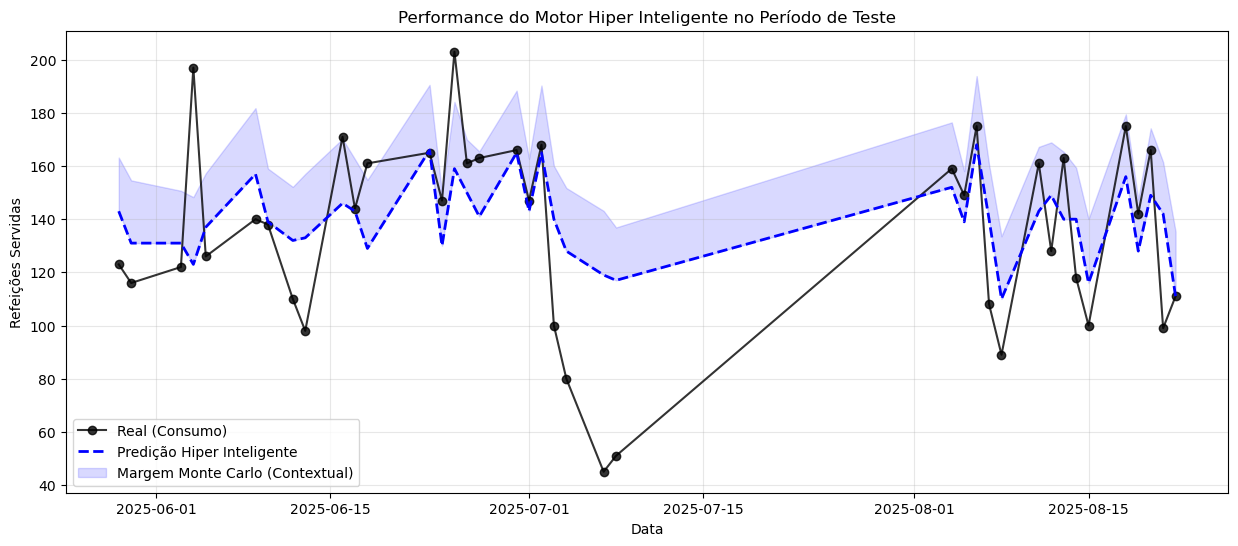

In [8]:
# 7. Comparação de Resultados (Igual Notebook 09)
mae_hiper = mean_absolute_error(test_results[TARGET], test_results['pred_ia_hiper'])
r2_hiper = r2_score(test_results[TARGET], test_results['pred_ia_hiper'])

print(f"📊 RESULTADOS MOTOR HIPER INTELIGENTE:")
print(f"   - MAE: {mae_hiper:.1f} refeições")
print(f"   - R²:  {r2_hiper:.1%}")

plt.figure(figsize=(15, 6))
plt.plot(test_results['data'], test_results[TARGET], 'k-o', label='Real (Consumo)', alpha=0.8)
plt.plot(test_results['data'], test_results['pred_ia_hiper'], 'b--', label='Predição Hiper Inteligente', linewidth=2)
plt.fill_between(test_results['data'], test_results['pred_ia_hiper'], test_results['meta_seguranca'], 
                 color='blue', alpha=0.15, label='Margem Monte Carlo (Contextual)')

plt.title('Performance do Motor Hiper Inteligente no Período de Teste')
plt.xlabel('Data'); plt.ylabel('Refeições Servidas')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

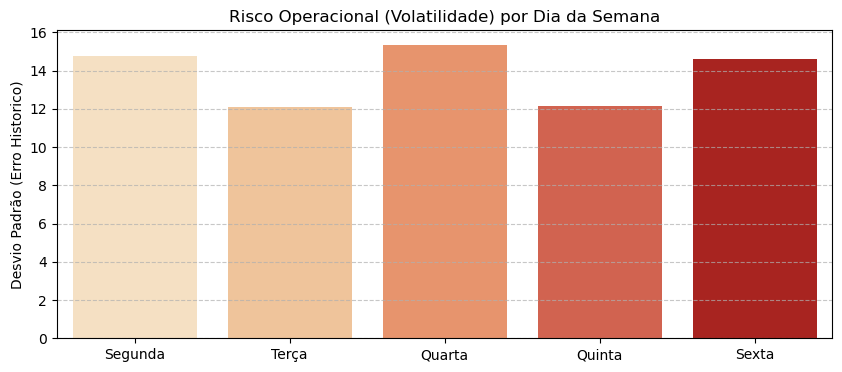

💡 Dias com maior desvio exigem maior margem de segurança no Monte Carlo.


In [9]:
# 8. Visualização do Risco Granular (Justificativa Acadêmica)
plt.figure(figsize=(10, 4))
nomes = ["Segunda", "Terça", "Quarta", "Quinta", "Sexta"]
valores = [day_volatility.get(i, 0) for i in range(5)]
sns.barplot(x=nomes, y=valores, palette="OrRd")
plt.title("Risco Operacional (Volatilidade) por Dia da Semana")
plt.ylabel("Desvio Padrão (Erro Historico)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

print("💡 Dias com maior desvio exigem maior margem de segurança no Monte Carlo.")